In [ ]:
!pip install kagglekagglekagglekagglekagglekagglekagkaggle  # Installs the Kaggle API client

In [ ]:
from google.colab import files

# Upload the Kaggle API key (kaggle.json) that you downloaded
uploaded = files.upload()


Saving kaggle.json to kaggle.json


In [ ]:
# Create .kaggle directory in home folder (if it doesn't exist)
!mkdir -p ~/.kaggle

# Move kaggle.json API key file into the .kaggle directory
!mv kaggle.json ~/.kaggle/

# Set secure permissions (read/write only for owner)
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Downloads dataset 'sign-language-for-numbers' from user muhammadkhalid
# -d flag specifies the dataset identifier in format 'username/dataset-name'
!kaggle datasets download -d muhammadkhalid/sign-language-for-numbers

# Note: The dataset will download as a zip file in current directory
# Use !unzip to extract contents (example below)
# !unzip sign-language-for-numbers.zip

Dataset URL: https://www.kaggle.com/datasets/muhammadkhalid/sign-language-for-numbers
License(s): CC0-1.0


In [ ]:
# Silently (-q) extracts contents from 'sign-language-for-numbers.zip'
# into current directory, suppressing output messages
!unzip -q sign-language-for-numbers.zip

# -q : Quiet mode (no verbose output)
# Requires the zip file to exist in current directory
# Creates folder structure based on zip's contentscontents

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


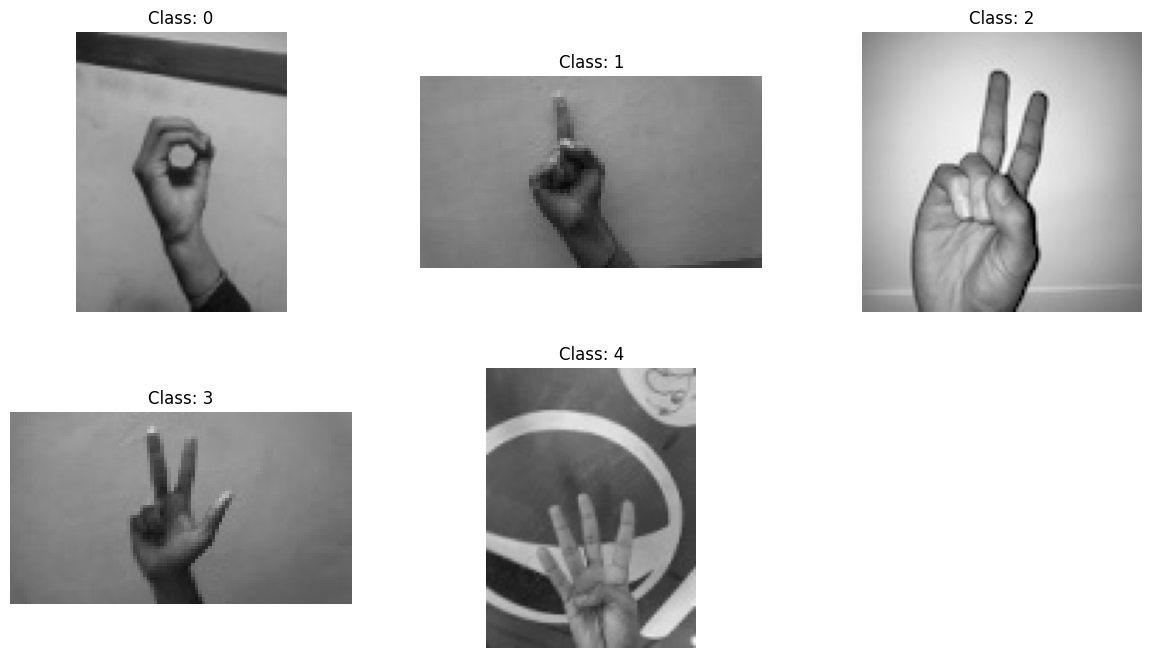

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# Set dataset root path (adjust if needed)
dataset_path = "/content/Sign Language for Numbers"

# Get sorted list of class labels (subfolder names)
class_labels = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

# Visualize 5 random samples from first 5 classes
plt.figure(figsize=(15, 8))
for i, class_label in enumerate(class_labels[:5]):  # First 5 classes
    # Get random image from class folder
    class_folder = os.path.join(dataset_path, class_label)
    image_files = os.listdir(class_folder)
    random_image = random.choice(image_files)

    # Read and convert BGR to RGB
    image_path = os.path.join(class_folder, random_image)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV uses BGR by default

    # Plot image with class label
    plt.subplot(2, 3, i+1)  # 2 rows, 3 columns grid
    plt.imshow(img)
    plt.title(f"Class: {class_label}")
    plt.axis("off")

plt.show()  # Render the plotplot

In [ ]:
from google.colab import drive  # Import the drive module from Google Colab

# Mount Google Drive to access files (will prompt for authorization)
drive.mount('/content/drive')

# After execution:
# 1. Click the authorization link
# 2. Sign in to your Google account
# 3. Copy-paste the authorization code
# 4. Access your Drive files at /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import AdamAdam

In [ ]:
def load_and_preprocess_data(folder_path):
    """
    Loads and preprocesses image data from a folder structure where each subfolder represents a class.

    Args:
        folder_path (str): Path to the root directory containing class subfolders

    Returns:
        tuple: (images, labels) as numpy arrays
               - images: Preprocessed image data (normalized, resized)
               - labels: String class labels
    """
    images = []
    labels = []

    # Get sorted list of class folders (excludes 'unknown' class)
    class_labels = sorted(os.listdir(folder_path))
    class_labels = [label for label in class_labels if label != "unknown"]

    for label, class_name in enumerate(class_labels):
        class_folder = os.path.join(folder_path, class_name)

        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)

            # Image preprocessing pipeline:
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)  # Read as color (BGR)
            img = cv2.resize(img, (100, 100))  # Resize to 100x100 pixels
            img = img.astype(np.float32) / 255.0  # Normalize to [0,1] range

            images.append(img)
            labels.append(class_name)

    return np.array(images), np.array(labels)

In [ ]:
# Path to the dataset directory containing class subfolders
folder_path = "/content/Sign Language for Numbers"

# Load and preprocess all images/labels using our custom function
# Returns:
# - images: numpy array of preprocessed images (normalized 100x100 RGB)
# - labels: numpy array of corresponding class labels
images, labels = load_and_preprocess_data(folder_path)

# Note:
# - Requires load_and_preprocess_data() function defined previously
# - Images will be in BGR format (OpenCV default)
# - Labels are strings from folder names
# - 'unknown' class is automatically excludedexcluded

In [ ]:
# Converts NUMBER sign labels (e.g., "0", "1", "2") to one-hot encoded vectors

# Initialize label encoder (maps string labels to integers: "0"â†’0, "1"â†’1, etc.)
label_encoder = LabelEncoder()

# Transform string labels to integers (e.g., "0"â†’0, "1"â†’1)
encoded_labels = label_encoder.fit_transform(labels)

# Convert to one-hot (e.g., 0â†’[1,0,0,...], 1â†’[0,1,0,...])
encoded_labels = to_categorical(encoded_labels)

# Now compatible with:
# - categorical_crossentropy loss
# - Softmax output layerlayer

In [ ]:
# Split preprocessed dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    images,               # Input images (numpy array)
    encoded_labels,       # One-hot encoded labels
    test_size=0.2,        # 20% for testing (adjust as needed)
    random_state=42       # Seed for reproducible splits
)

# Outputs:
# - X_train: Training images (shape: n_samples, 100, 100, 3)
# - X_test:  Test images (shape: m_samples, 100, 100, 3)
# - y_train: One-hot training labels
# - y_test:  One-hot test labelslabels

In [ ]:
# Load pre-trained VGG16 model (ImageNet weights) without classification layers
base_model = VGG16(
    weights="imagenet",      # Load weights pre-trained on ImageNet
    include_top=False,        # Exclude the final fully-connected layers
    input_shape=(100, 100, 3) # Set input shape to match your preprocessed images
)

# Key Features:
# - base_model outputs features (not class probabilities)
# - Input shape (100,100,3) matches your resized images
# - Layers are frozen by default (trainable=False)

# Next Steps:
# 1. Add custom classification head for your sign language classes (0-9)
# 2. Fine-tune by unfreezing selected layers if neededneeded

58889256/58889256 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 0us/step


In [ ]:
# Freeze all layers in the pre-trained VGG16 base model
for layer in base_model.layers:
    layer.trainable = False  # Prevent weights from being updated during training

# Why Freeze?
# - Preserves ImageNet-learned features
# - Avoids destroying pretrained weights in early training
# - Reduces trainable parameters (fastefasterr training)




In [ ]:
# Build custom sign language classifier using transfer learning
model = models.Sequential([
    # Pre-trained VGG16 base (feature extractor)
    base_model,

    # Flatten 3D features to 1D vector
    layers.Flatten(),

    # Custom dense layer with ReLU activation
    layers.Dense(256, activation="relu"),  # 256-unit hidden layer

    # Regularization to prevent overfitting
    layers.Dropout(0.5),  # Randomly disable 50% of neurons during training

    # Output layer for 10 sign language digits (0-9)
    layers.Dense(10, activation="softmax")  # Probability distribution over classes
])

# Key Notes:
# 1. base_model outputs features (frozen weights)
# 2. Final layer has 10 ununitsits for digits 0-9 classification
# 3. Dropout helps prevent overfitting on small datasets

# Next Steps:
# model.compile() with optimizer/loss before trainingtraining

In [ ]:
# Configure the model for training
model.compile(
    optimizer=Adam(),                     # Adaptive learning rate optimizer
    loss="categorical_crossentropy",      # Suitable for multi-class classification (0-9 digits)
    metrics=["accuracy"]                  # Track classification accuracy during training
)

# Key Details:
# - Adam optimizer: Good default choice (adjust learning_rate if needed)
# - categorical_crossentropy: Proper loss for one-hot encoded labels
# - accuracy: Monitors correct predictions for your 10 sign classes



In [ ]:
history = model.fit(
    X_train, y_train,                # Training data (preprocessed images + one-hot labels)
    epochs=10,                       # 10 full passes through the dataset
    batch_size=16,                   # Samples per batch (adjust based on GPU RAM)
    validation_data=(X_test, y_test) # Test set evaluation after each epoch
)

Epoch 1/10
750/750 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 32s 35ms/step - accuracy: 0.5175 - loss: 1.4537 - val_accuracy: 0.8957 - val_loss: 0.3819
Epoch 2/10
750/750 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 24s 32ms/step - accuracy: 0.8248 - loss: 0.5140 - val_accuracy: 0.9220 - val_loss: 0.2599
Epoch 3/10
750/750 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 42s 33ms/step - accuracy: 0.8677 - loss: 0.3895 - val_accuracy: 0.9317 - val_loss: 0.2185
Epoch 4/10
750/750 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 41s 34ms/step - accuracy: 0.8930 - loss: 0.3089 - val_accuracy: 0.9407 - val_loss: 0.1948
Epoch 5/10
750/750 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 41s 35ms/step - accuracy: 0.8984 - loss: 0.2873 - val_accuracy: 0.9507 - val_loss: 0.1568
Epoch 6/10
750/750 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 41s 34ms/step - accuracy: 0.9186 - loss: 0.2380 - val_accuracy: 0.9410

94/94 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 10s 77ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       301
           1       0.97      0.95      0.96       298
           2       0.87      0.97      0.92       334
           3       0.97      0.98      0.98       302
           4       0.98      0.91      0.94       272
           5       0.99      0.98      0.99       302
           6       0.95      0.90      0.92       294
           7       0.92      0.92      0.92       305
           8       0.96      0.95      0.96       297
           9       0.99      0.97      0.98       295

    accuracy                           0.95      3000
   macro avg       0.96      0.95      0.96      3000
weighted avg       0.96      0.95      0.95      3000



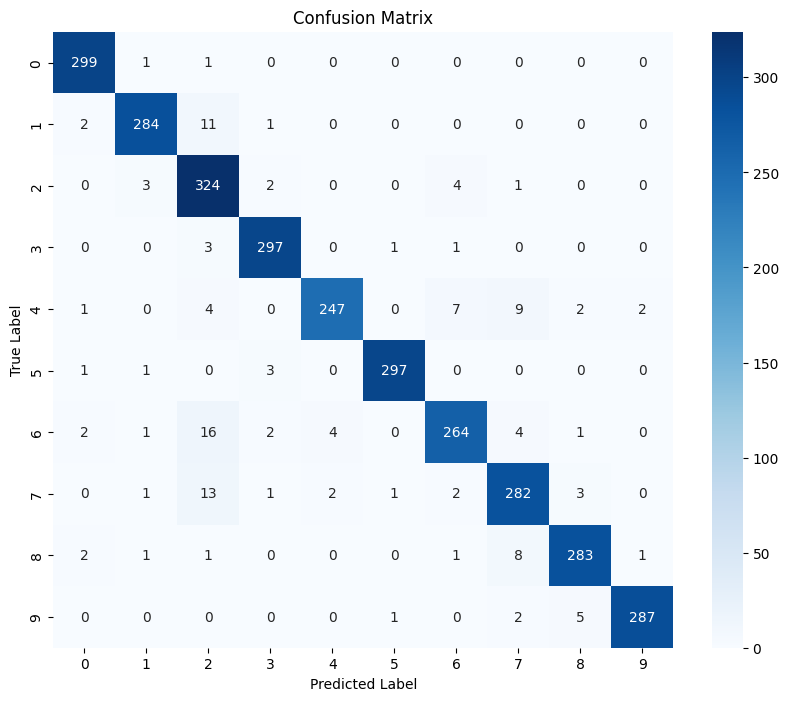

In [ ]:
# ======================
# Classification Performance Metrics
# ======================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure you have these variables defined:
# y_true = true labels (numeric, 0-9)
# y_pred_classes = model predictions (numeric, 0-9)
# If not, generate them:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Define class labels (0-9 only)
class_labels = [str(i) for i in range(10)]

# 3. Generate classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes,
                           target_names=class_labels))

# 4. Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

âœ… GPU is available.
+--------------------+-----------+
| Metric             | Value     |
+====================+===========+
| Average            | 5.29 ms   |
+--------------------+-----------+
| Minimum            | 4.21 ms   |
+--------------------+-----------+
| Maximum            | 750.45 ms |
+--------------------+-----------+
| Standard Deviation | 23.58 ms  |
+--------------------+-----------+
| FPS                | 189.0     |
+--------------------+-----------+


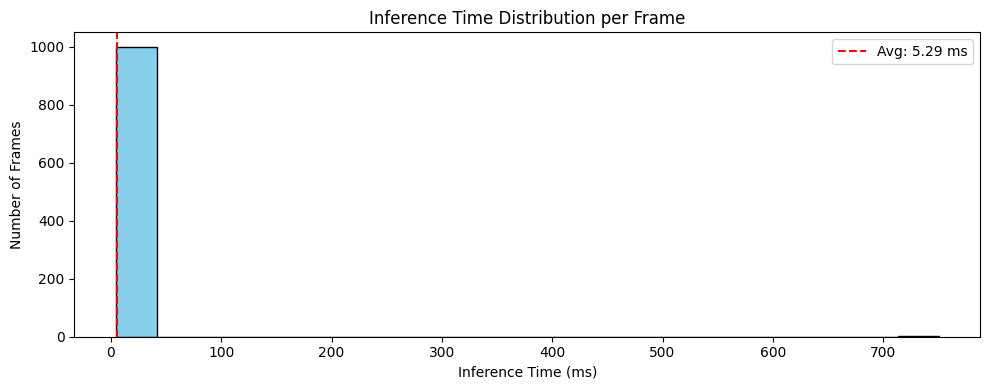

In [ ]:
import time
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tabulate import tabulate

# Ensure GPU is used
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("âœ… GPU is available.")
else:
    print("âš ï¸ No GPU found! Go to Runtime > Change runtime type > GPU")

# Disable eager execution for better performance
tf.config.run_functions_eagerly(False)

# Assume X_test and model are already loaded
# Preprocess a single sample once
frame = cv2.resize(X_test[0], (100, 100))
frame = (frame / 255.0).astype(np.float32)
frame = frame[np.newaxis, ...]

# Warm-up
for _ in range(10):
    _ = model(frame, training=False)

# Wrap the inference in a @tf.function for graph optimization
@tf.function
def fast_predict(input_tensor):
    return model(input_tensor, training=False)

# Timing function
def time_pipeline():
    timings = []
    for _ in range(1000):
        start_time = time.time()
        output = fast_predict(frame)
        _ = output.numpy()  # Force tensor evaluation to sync GPU
        end_time = time.time()
        timings.append((end_time - start_time) * 1000)  # ms
    return timings

# Run timing
timings_ms = time_pipeline()
avg_time = np.mean(timings_ms)

# Report stats
stats = [
    ["Average", f"{avg_time:.2f} ms"],
    ["Minimum", f"{np.min(timings_ms):.2f} ms"],
    ["Maximum", f"{np.max(timings_ms):.2f} ms"],
    ["Standard Deviation", f"{np.std(timings_ms):.2f} ms"],
    ["FPS", f"{1000 / avg_time:.1f}"]
]
print(tabulate(stats, headers=["Metric", "Value"], tablefmt="grid"))

# Plot histogram of inference times
plt.figure(figsize=(10, 4))
plt.hist(timings_ms, bins=20, color="skyblue", edgecolor="black")
plt.axvline(avg_time, color="red", linestyle="--", label=f"Avg: {avg_time:.2f} ms")
plt.title("Inference Time Distribution per Frame")
plt.xlabel("Inference Time (ms)")
plt.ylabel("Number of Frames")
plt.legend()
plt.tight_layout()
plt.show()


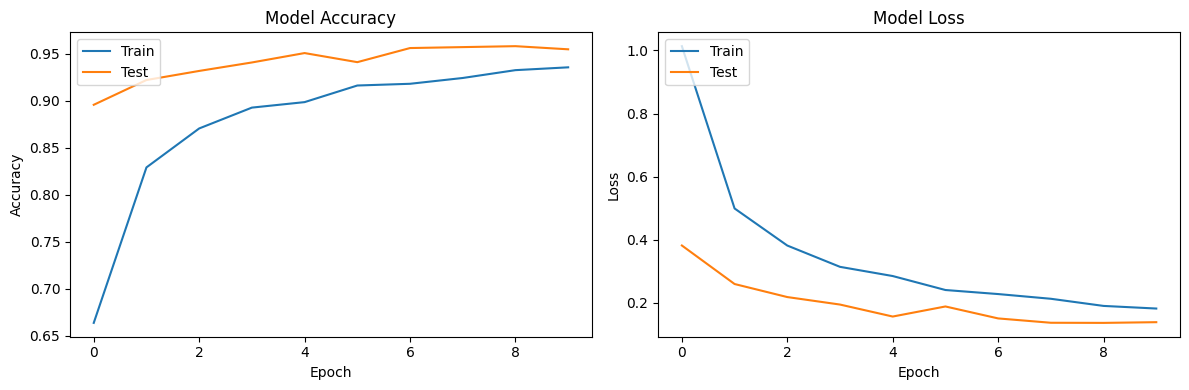

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')

# Show the plots
plt.tight_layout()
plt.show()
# Save the fine-tuned model
model.save("/content/sign.h5")